# 05 - Modèle Forêt Aléatoire

## 1. Objectif et protocole

Quantifier la robustesse d'un ensemble d'arbres sans prétraitement et documenter son interpretabilite exploratoire.

Protocole publie dans ce notebook:
- `validation croisée simple` stratifiée pour comparer les variantes non tunées.
- recherche sur grille pour cartographier l'espace hyperparametrique de maniere exploratoire.
- `validation croisée imbriquée` pour la performance finale confirmatoire.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.config import RESULTS_DIR
from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    matrice_confusion_normalisee,
    classes_difficiles,
    top_confusions,
)
from src.notebook_support import (
    calculer_importance_oob_foret_exploratoire,
    calculer_metriques_classes_depuis_predictions,
    charger_ou_generer_predictions_variante,
    construire_tableau_gaps,
    construire_resume_confusions_variantes,
    construire_tableau_plis_externes,
    construire_tableau_corroboration_descriptive_variantes,
    construire_tableau_corroboration_secondaire,
    construire_tableau_variantes,
    creer_contexte_notebook,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    executer_verifications_validite,
)
from src.plots import (
    tracer_comparaison_variantes,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_hyperparametre_vs_performance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.evaluation.diagnostics_specifiques import oob_vs_n_estimators
from src.plots.specifiques.foret_aleatoire import tracer_oob_vs_n_estimators

In [2]:
MODEL_NAME = "foret_aleatoire"
OUTPUT_ROOT = RESULTS_DIR
ctx = creer_contexte_notebook(MODEL_NAME, output_root=OUTPUT_ROOT)
spec = ctx.spec
definition = ctx.definition
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

protocole = pd.DataFrame(
    [
        ("Modèle", definition["nom_affiche"]),
        ("Famille", definition["famille"]),
        ("Metrique principale", "macro-F1"),
        ("Exploration", "validation croisée simple + recherche sur grille"),
        ("Confirmation", "validation croisée imbriquée"),
    ],
    columns=["axe", "choix"],
)
display(protocole)


,axe,choix
0,Modèle,Forêt aléatoire
1,Famille,ensemble
2,Metrique principale,macro-F1
3,Exploration,validation croisée simple + recherche sur grille
4,Confirmation,validation croisée imbriquée


## 2. Signal attendu et design experimental

**Design experimental**
- La foret aleatoire est etudiee sans scaling ni PCA.
- La variante de profondeur restreinte sert de sanity check de complexite, pas de baseline amelioree officielle.
- Les importances publiees dans le notebook doivent venir d'un diagnostic OOB et rester exploratoires.

**Signal attendu**
- Une forte performance sans prétraitement confirmerait la robustesse du modele sur ce tabulaire multiclasses.
- Les importances OOB ne doivent servir qu'a illustrer des tendances descriptives, pas a inferrer une causalite.

**Refutation pratique**
- Si ces motifs n'apparaissent pas, ou s'inversent dans la `validation croisée imbriquée`, l'hypothese du modele n'est pas consideree comme confirmee.


In [3]:
design_table = pd.DataFrame(
    {
        "variante": [variant.name for variant in spec.untuned_variants],
        "type": [variant.kind for variant in spec.untuned_variants],
        "parametres_forces": [variant.params or {} for variant in spec.untuned_variants],
    }
)
display(design_table)


,variante,type,parametres_forces
0,default,simple,{}
1,restricted_depth,simple,{'max_depth': 10}


## 3. Résultats exploratoires non tunés

Cette section sert a mesurer les variantes sans selection d'hyperparametres finale.
Les écarts entraînement-validation restent uniquement descriptifs à ce stade.


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.9785,0.0065,0.9764,0.0094,1.0000,1.0000,0.0215,0.0236,9.1642,cv_n_jobs=1
1,restricted_depth,simple_cv,improved_untuned,0.9445,0.0151,0.9345,0.0129,0.9997,0.9997,0.0552,0.0651,5.4234,cv_n_jobs=1


,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.0215,0.0236
1,restricted_depth,0.0552,0.0651


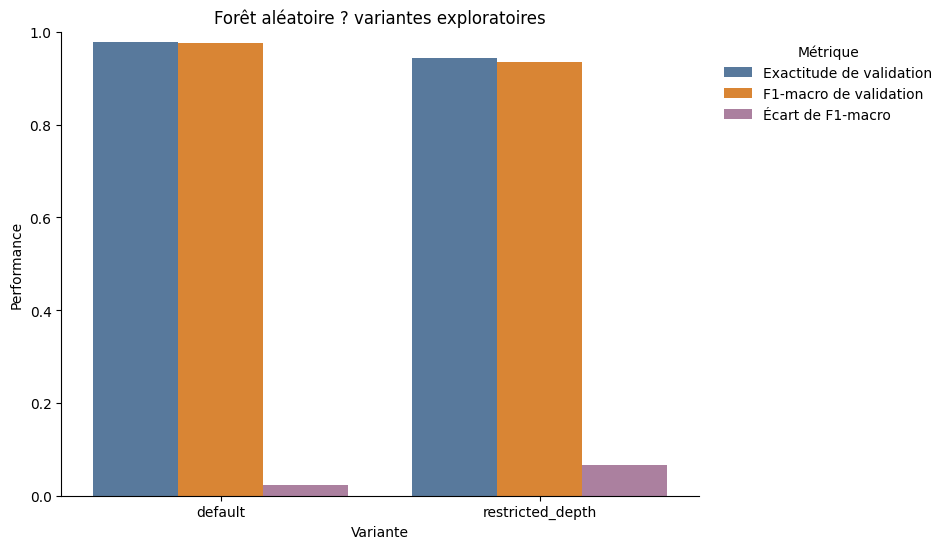

In [4]:
untuned_results = evaluer_variantes_untuned(ctx)
untuned_table = construire_tableau_variantes(untuned_results, None)
gap_table = construire_tableau_gaps(untuned_results)

display(untuned_table.round(4))
display(gap_table.round(4))

tracer_comparaison_variantes(
    untuned_table[[
        "variante",
        "val_accuracy_mean",
        "val_f1_macro_mean",
        "generalization_gap_f1_macro",
    ]],
    ["val_accuracy_mean", "val_f1_macro_mean", "generalization_gap_f1_macro"],
    titre=f"{definition['nom_affiche']} ? variantes exploratoires",
)
plt.show()


## 4. Résultat confirmatoire ajusté

Les cartes du recherche sur grille restent exploratoires. La seule performance finale a commenter
comme resultat confirmatoire est la ligne `ajustée` obtenue en `validation croisée imbriquée`.


In [5]:
tuning = executer_tuning_confirmatoire(ctx, untuned_results)
summary_table = construire_tableau_variantes(untuned_results, tuning["metrics"])
fold_table = construire_tableau_plis_externes(tuning["nested"])
grid_results = tuning["grid_results"].copy()
shortlist = grid_results.sort_values("rank_test_f1_macro").head(10)

display(summary_table.round(4))
display(fold_table.round(4))

colonnes_shortlist = [
    colonne
    for colonne in [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_fit_time",
    ] + [col for col in shortlist.columns if col.startswith("param_")]
    if colonne in shortlist.columns
]
display(shortlist[colonnes_shortlist].round(4))

if spec.tuning_heatmap_axes is not None:
    axe_x, axe_y = spec.tuning_heatmap_axes
    colonne_facette = spec.tuning_facet_column
    if colonne_facette and colonne_facette in grid_results.columns:
        for valeur_facette, sous_tableau in grid_results.groupby(colonne_facette):
            if sous_tableau[[axe_x, axe_y]].drop_duplicates().shape[0] != len(sous_tableau):
                continue
            tracer_heatmap_tuning(
                sous_tableau,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} - tuning exploratoire ({colonne_facette}={valeur_facette})",
            )
            plt.show()
    elif axe_x in grid_results.columns and axe_y in grid_results.columns:
        if grid_results[[axe_x, axe_y]].drop_duplicates().shape[0] == len(grid_results):
            tracer_heatmap_tuning(
                grid_results,
                x=axe_x,
                y=axe_y,
                valeur="mean_test_f1_macro",
                titre=f"{definition['nom_affiche']} - tuning exploratoire",
            )
            plt.show()
        else:
            tracer_hyperparametre_vs_performance(
                grid_results,
                x=axe_x,
                y="mean_test_f1_macro",
                hue=axe_y,
                titre=f"{definition['nom_affiche']} - lecture exploratoire du tuning",
            )
            plt.show()


,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,default,simple_cv,baseline,0.9785,0.0065,0.9764,0.0094,1.0000,1.0000,0.0215,0.0236,9.1642,cv_n_jobs=1
1,tuned,nested_cv,tuned,0.9747,0.0089,0.9702,0.0140,NaN,NaN,NaN,NaN,250.1117,cv_n_jobs=1
2,restricted_depth,simple_cv,improved_untuned,0.9445,0.0151,0.9345,0.0129,0.9997,0.9997,0.0552,0.0651,5.4234,cv_n_jobs=1


,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,1.0,1.0,0.9686,0.9650,53.8583,0.0233,0.9582
1,2,1.0,1.0,0.9811,0.9811,48.8201,0.0258,0.9646
2,3,1.0,1.0,0.9684,0.9636,49.0275,0.0332,0.9745
3,4,1.0,1.0,0.9684,0.9535,47.5979,0.0244,0.9631
4,5,1.0,1.0,0.9873,0.9879,50.1822,0.0292,0.9638


,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_fit_time,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators
2,1,0.9740,0.0013,1.3352,None,sqrt,2,200
1,2,0.9715,0.0067,2.9005,None,sqrt,1,400
3,3,0.9700,0.0021,2.6298,None,sqrt,2,400
0,4,0.9686,0.0059,1.5628,None,sqrt,1,200
5,5,0.9685,0.0057,2.5529,20,sqrt,1,400
6,6,0.9669,0.0067,1.1959,20,sqrt,2,200
7,7,0.9667,0.0068,2.6432,20,sqrt,2,400
4,8,0.9628,0.0106,1.2819,20,sqrt,1,200


## 5. Vérifications de validité scientifique

Cette section impose le même contrat minimal dans tous les notebooks :
référence DummyClassifier, test de bruit aléatoire et rappel protocolaire.


In [6]:
validite = executer_verifications_validite(ctx)
display(Markdown(f"**Note protocolaire.** {validite['note']}"))
display(validite["dummy"].round(4))
display(validite["random_noise"].round(4))


**Note protocolaire.** Les variantes non tunées restent exploratoires ; les figures réapprises sur le sous-ensemble de développement (80 %) aussi. Les prédictions hors pli de la variante ajustée sont des diagnostics descriptifs confirmatoires, mais seule la performance de la variante ajustée en validation croisée imbriquée sert au classement final inter-modèles.

,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,reference
0,0.0063,0.0,0.0001,0.0,0.011,0.0002,0.0008,0.002,0.028,5,dummy,most_frequent,DummyClassifier


,val_accuracy_mean,val_f1_macro_mean,chance_level,near_chance,reference
0,0.0013,0.001,0.0101,True,Bruit aleatoire


## 6. Diagnostics du modele

Les tableaux et graphiques issus des prédictions `hors pli` de la `validation croisée imbriquée` sont confirmatoires.
Les diagnostics issus d'un réapprentissage global ou de la recherche sur grille complète sont explicitement exploratoires.


,classe,precision,recall,f1,support,fpr,fnr,specificite
0,Quercus_Palustris,0.8571,0.750,0.8000,8,0.0013,0.250,0.9987
1,Quercus_Greggii,1.0000,0.750,0.8571,8,0.0000,0.250,1.0000
2,Crataegus_Monogyna,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
3,Eucalyptus_Neglecta,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
4,Pterocarya_Stenoptera,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
5,Quercus_Agrifolia,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
6,Magnolia_Salicifolia,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
7,Quercus_Coccifera,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000
8,Quercus_Shumardii,0.8750,0.875,0.8750,8,0.0013,0.125,0.9987
9,Quercus_Suber,1.0000,0.875,0.9333,8,0.0000,0.125,1.0000


,classe_vraie,classe_predite,nombre_erreurs
0,Crataegus_Monogyna,Morus_Nigra,1
1,Eucalyptus_Neglecta,Eucalyptus_Glaucescens,1
2,Magnolia_Salicifolia,Magnolia_Heptapeta,1
3,Populus_Adenopoda,Quercus_Ilex,1
4,Pterocarya_Stenoptera,Alnus_Cordata,1
5,Quercus_Agrifolia,Quercus_Pontica,1
6,Quercus_Coccifera,Populus_Grandidentata,1
7,Quercus_Greggii,Quercus_Pubescens,1
8,Quercus_Greggii,Tilia_Platyphyllos,1
9,Quercus_Infectoria_sub,Cytisus_Battandieri,1


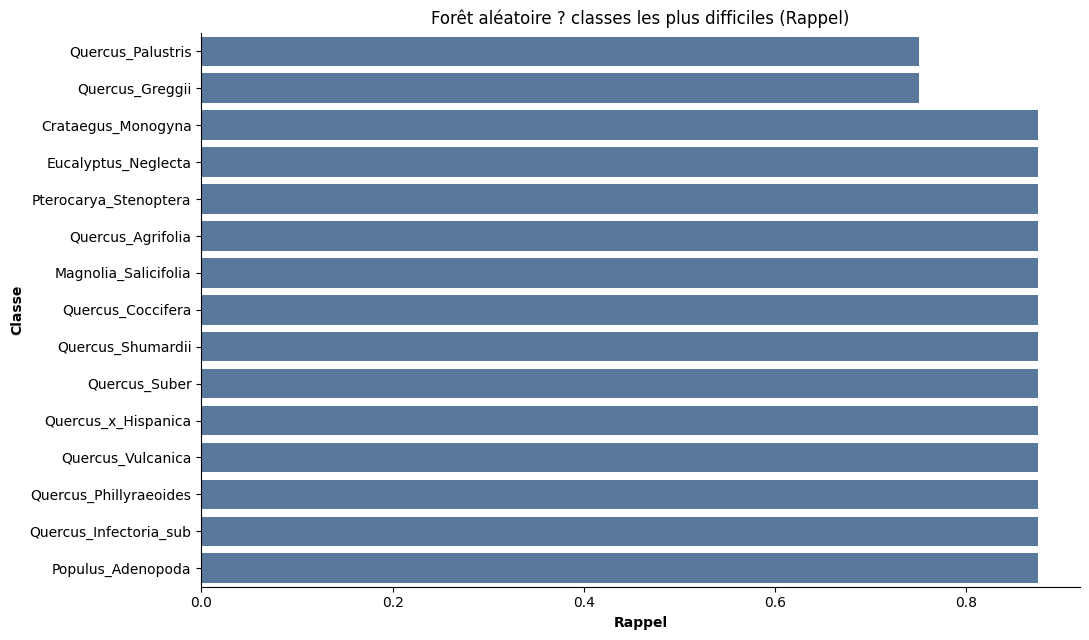

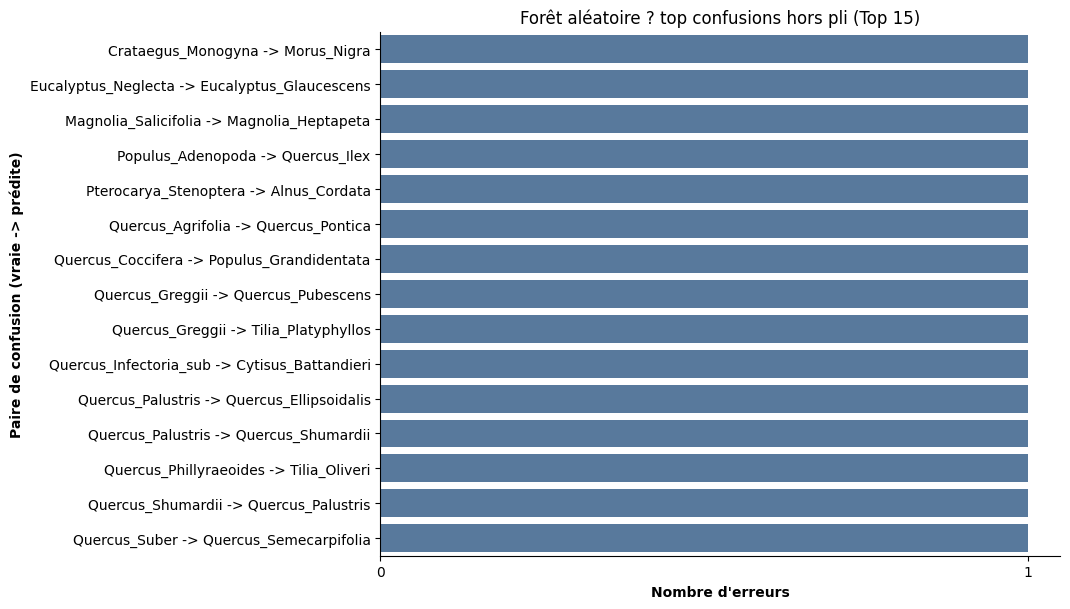

,top_1_accuracy,top_5_accuracy,confiance_moyenne,confiance_erreurs,brier_multiclasse
0,0.9747,0.9987,0.4412,0.1986,0.357


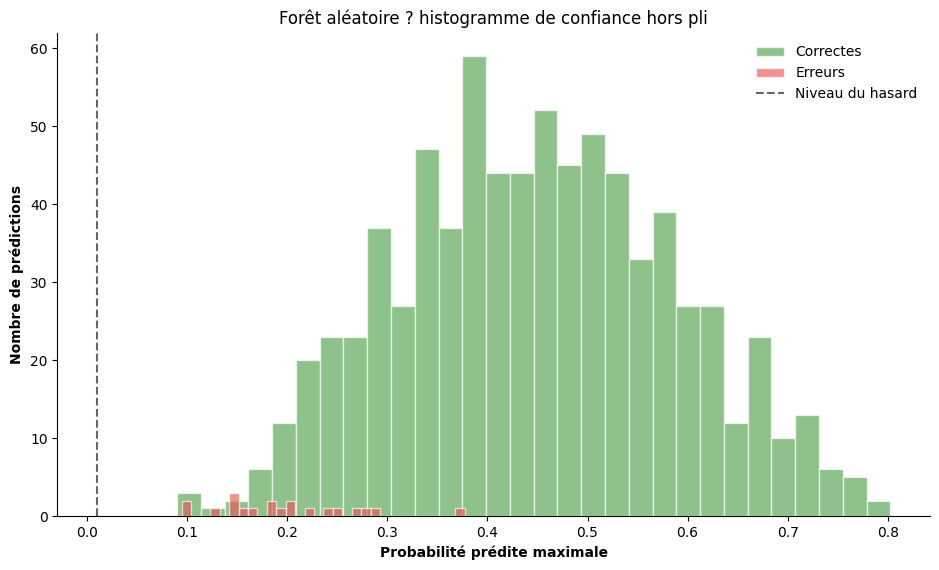

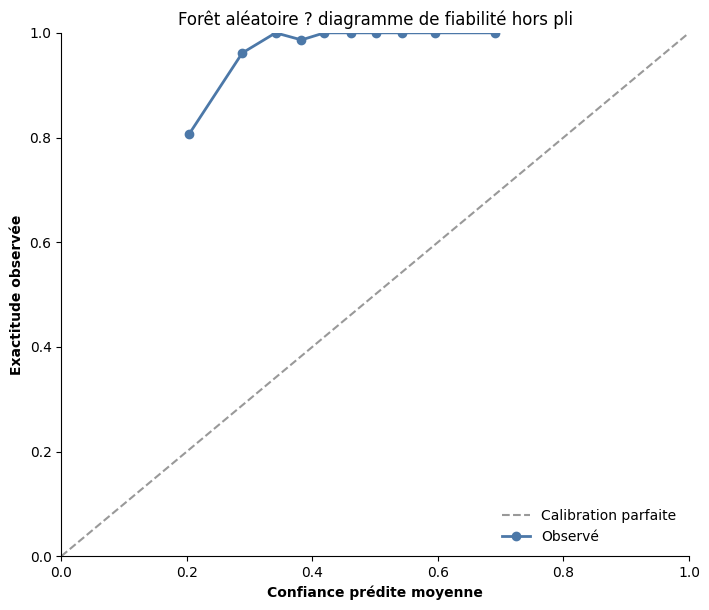

In [7]:
predictions_tuned = tuning["nested"]["oof_predictions"]
classes_table = calculer_metriques_classes_depuis_predictions(predictions_tuned, label_encoder)
difficult_classes = classes_difficiles(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
    metrique="recall",
)
confusions_table = top_confusions(
    predictions_tuned["y_true"].to_numpy(),
    predictions_tuned["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)

display(difficult_classes.round(4))
display(confusions_table.round(4))

tracer_metrique_par_classe(
    classes_table,
    metrique="recall",
    top_n=15,
    ordre="asc",
    titre=f"{definition['nom_affiche']} ? classes les plus difficiles",
)
plt.show()

if not confusions_table.empty:
    tracer_top_confusions(
        confusions_table,
        top_n=min(15, len(confusions_table)),
        titre=f"{definition['nom_affiche']} ? top confusions hors pli",
    )
    plt.show()

probabilites_tuned = tuning["nested"].get("oof_probabilities")
if spec.supports_probabilities and probabilites_tuned is not None:
    topk = calculer_top_k_accuracies(probabilites_tuned)
    confiance = calculer_statistiques_confiance(probabilites_tuned)
    brier = calculer_brier_score_multiclasse(probabilites_tuned)
    tableau_probabilites = pd.DataFrame(
        [
            {
                "top_1_accuracy": topk["top_1_accuracy"],
                "top_5_accuracy": topk["top_5_accuracy"],
                "confiance_moyenne": confiance["confiance_moyenne"],
                "confiance_erreurs": confiance["confiance_erreurs"],
                "brier_multiclasse": brier,
            }
        ]
    )
    display(tableau_probabilites.round(4))
    tracer_histogramme_confiance(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? histogramme de confiance hors pli",
    )
    plt.show()
    tracer_reliability_diagram(
        probabilites_tuned,
        titre=f"{definition['nom_affiche']} ? diagramme de fiabilité hors pli",
    )
    plt.show()
else:
    display(Markdown("_Aucun diagnostic probabiliste n'est publie pour ce modele dans cette passe._"))


### Matrices de confusion par variante

Les matrices ci-dessous enrichissent la lecture des erreurs pour chaque variante du modele.
- pour la variante ajustée, les prédictions proviennent des artefacts `hors pli` de la `validation croisée imbriquée` ;
- pour les variantes non ajustées, les prédictions sont reconstruites en `validation croisée simple` avec le protocole partage.

Cette comparaison reste descriptive : elle permet d'observer la structure des erreurs sans transformer
les variantes exploratoires en resultats confirmatoires.


,variante,evaluation_stage,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,confusion_dominante,nombre_erreurs_dominantes
0,default,baseline,0.9764,0.9785,0.0236,Crataegus_Monogyna -> Morus_Nigra,1
1,restricted_depth,improved_untuned,0.9345,0.9445,0.0651,Quercus_Canariensis -> Quercus_Brantii,3
2,tuned,tuned,0.9702,0.9747,NaN,Crataegus_Monogyna -> Morus_Nigra,1


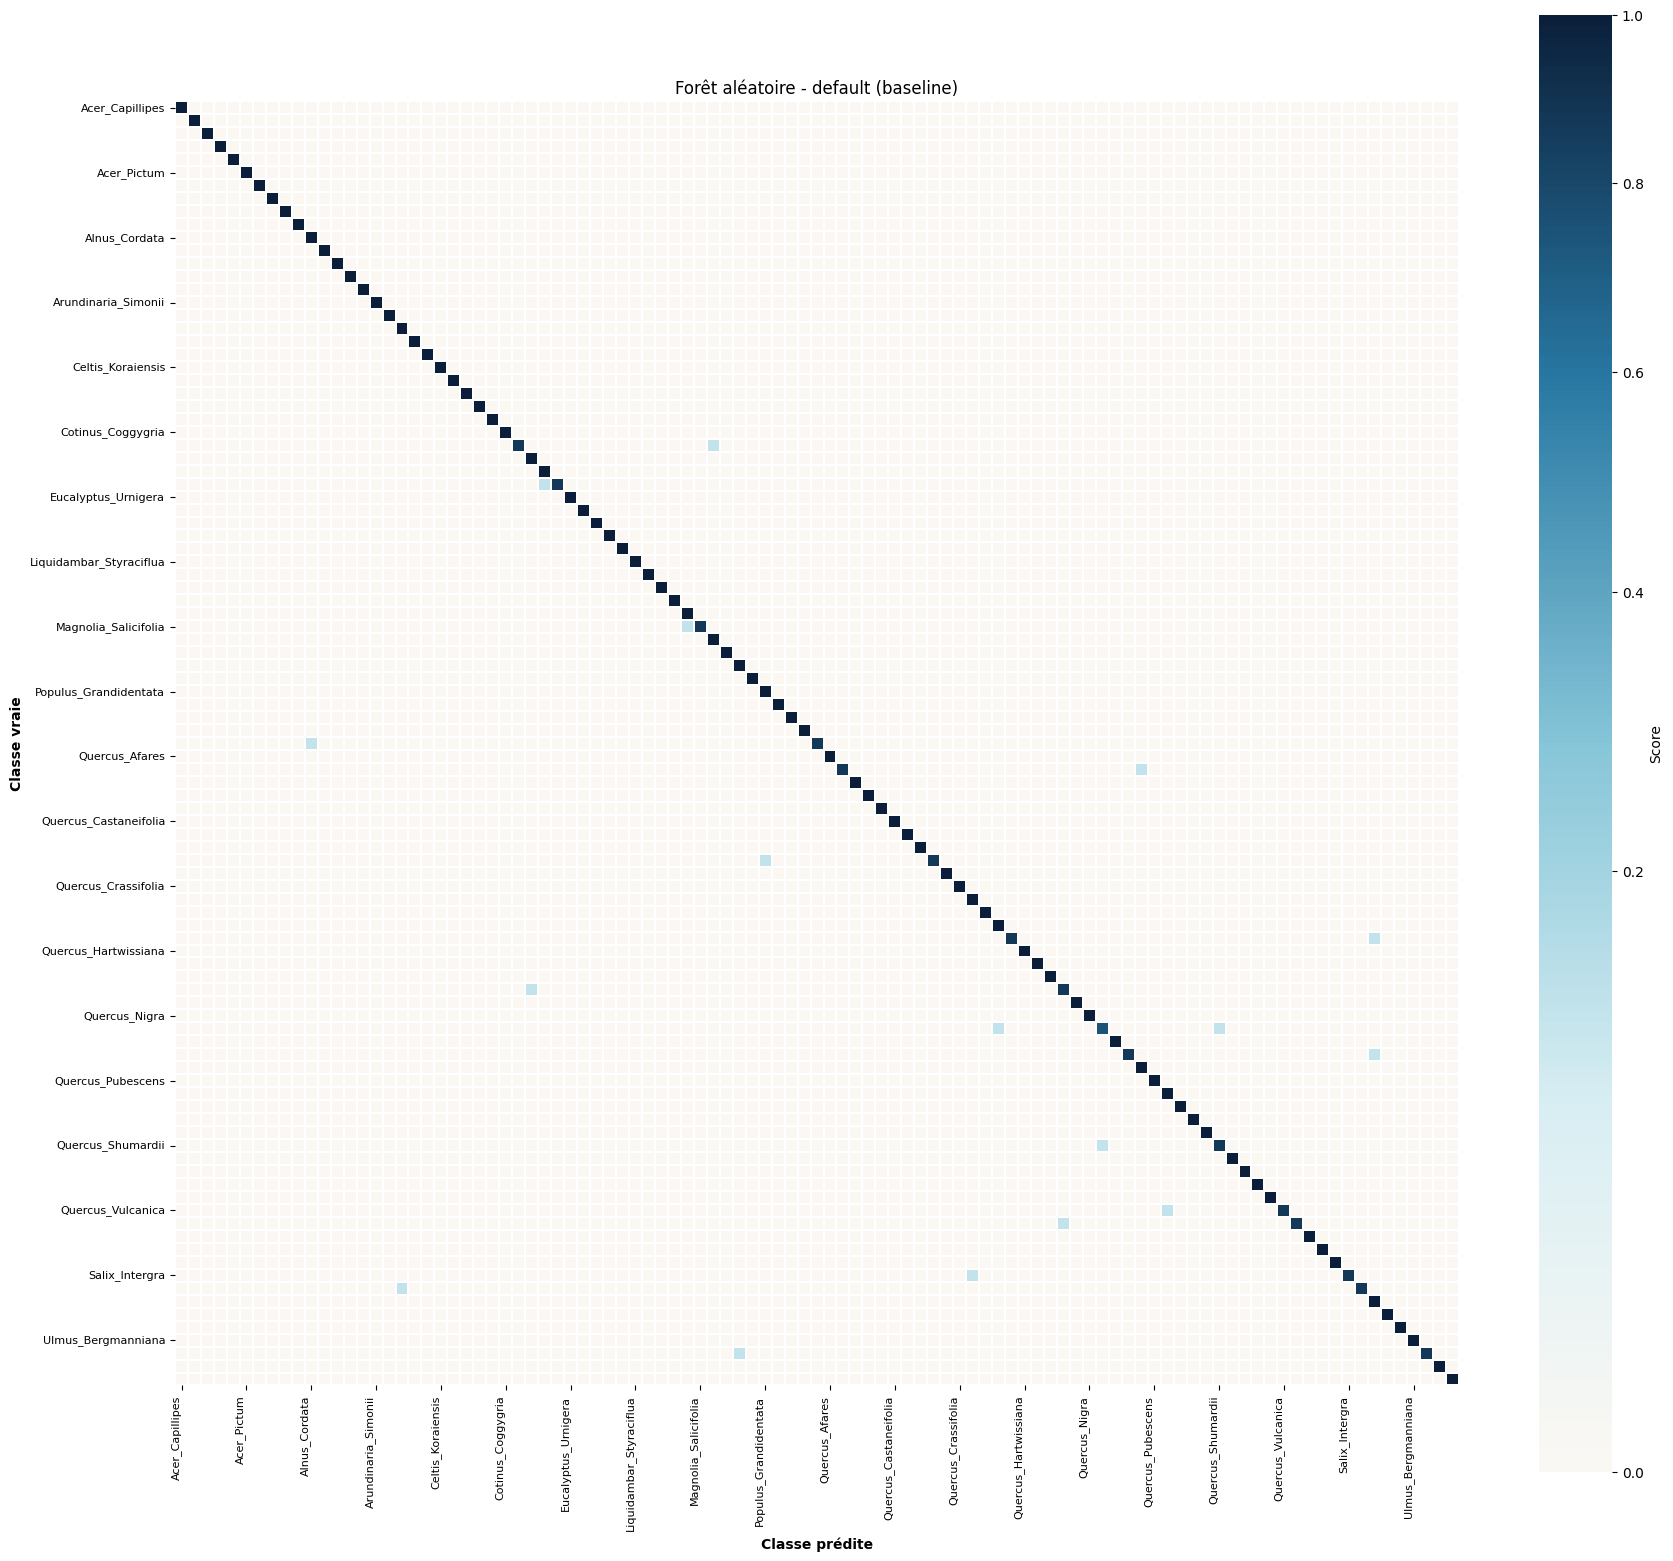

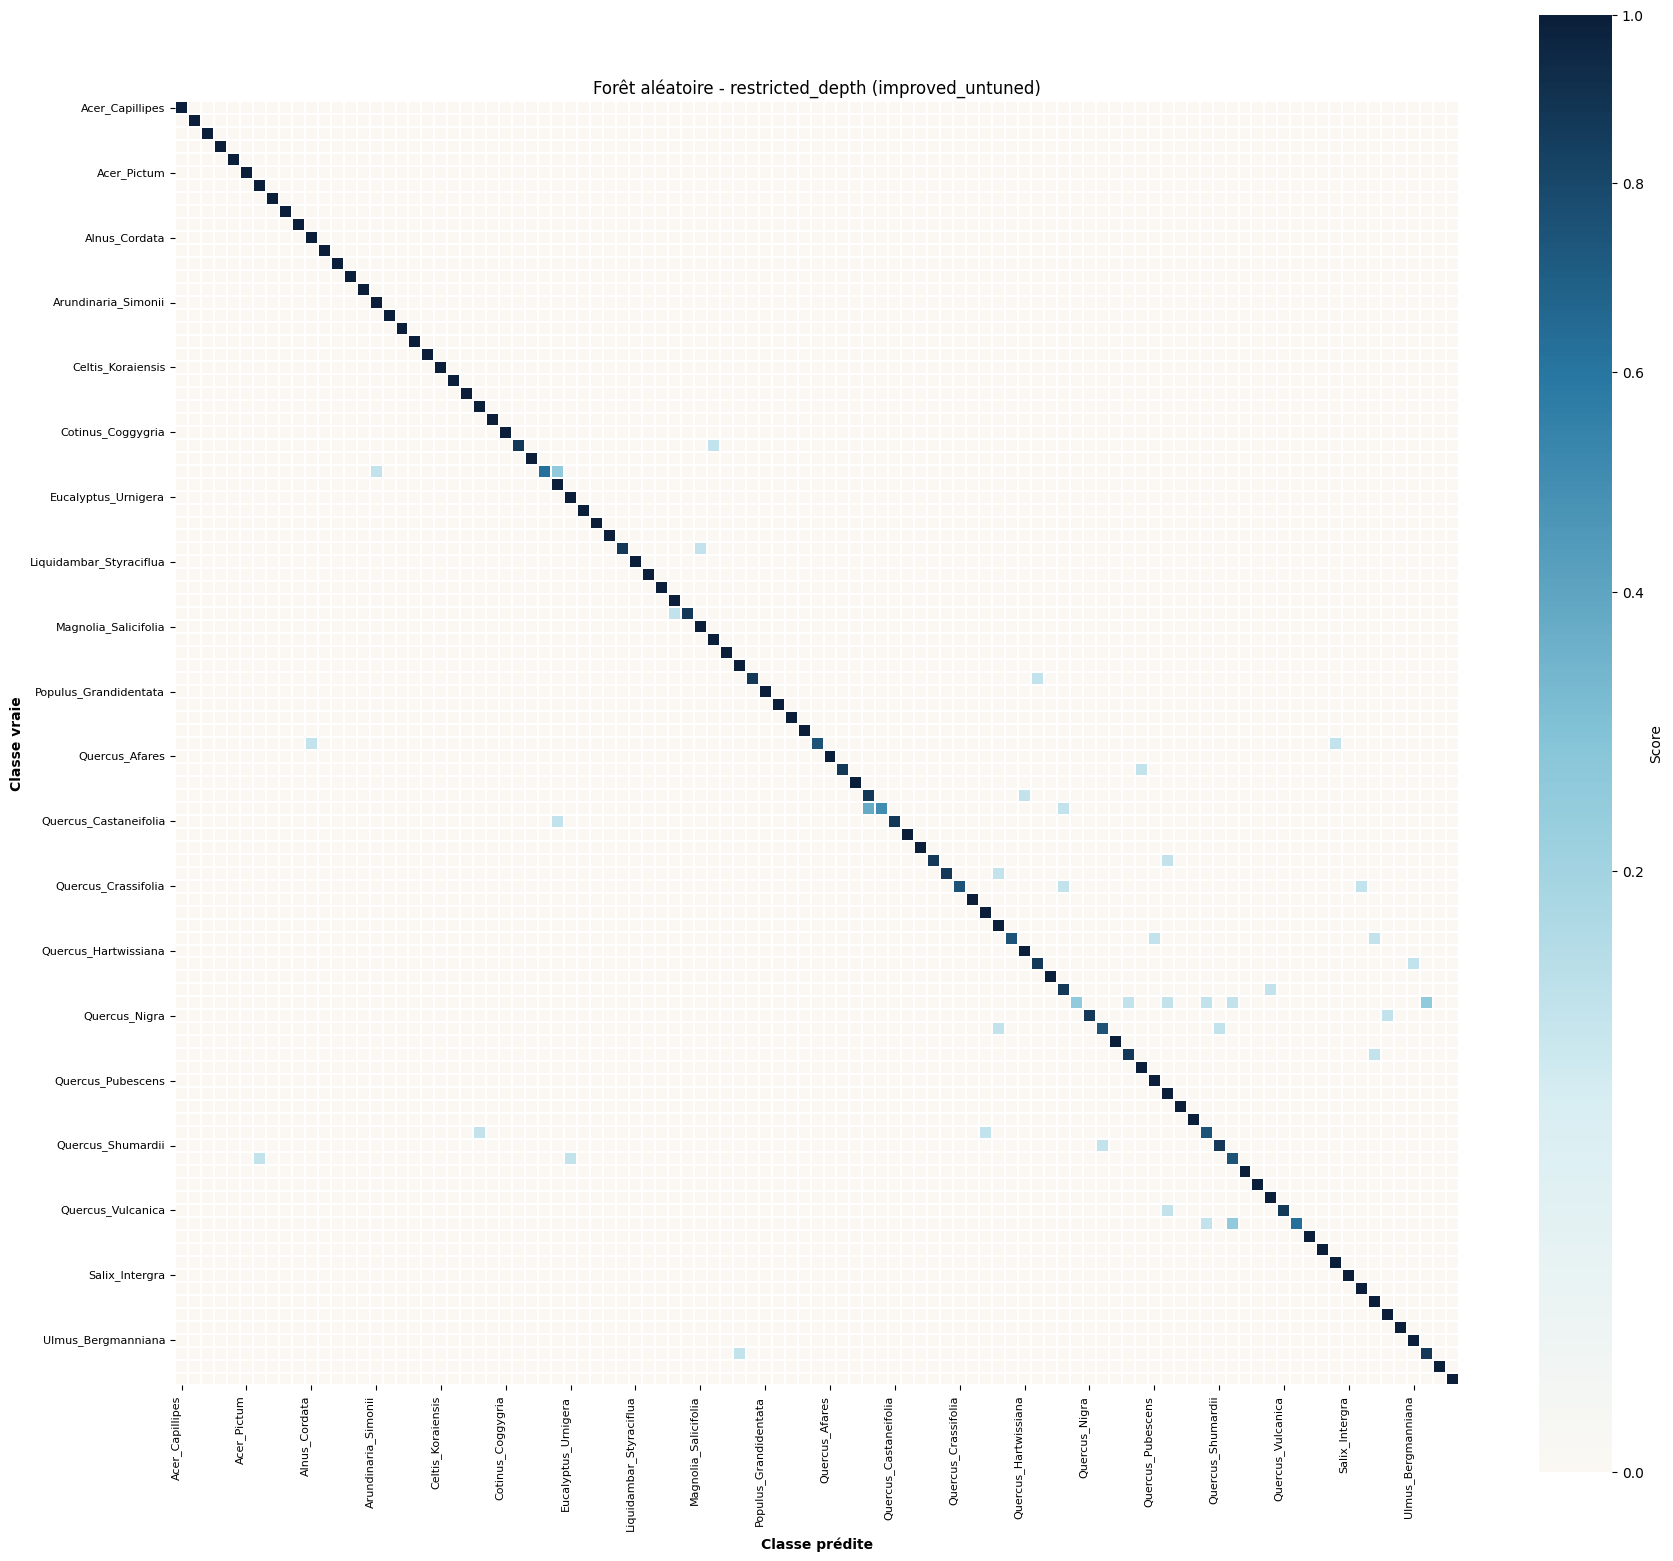

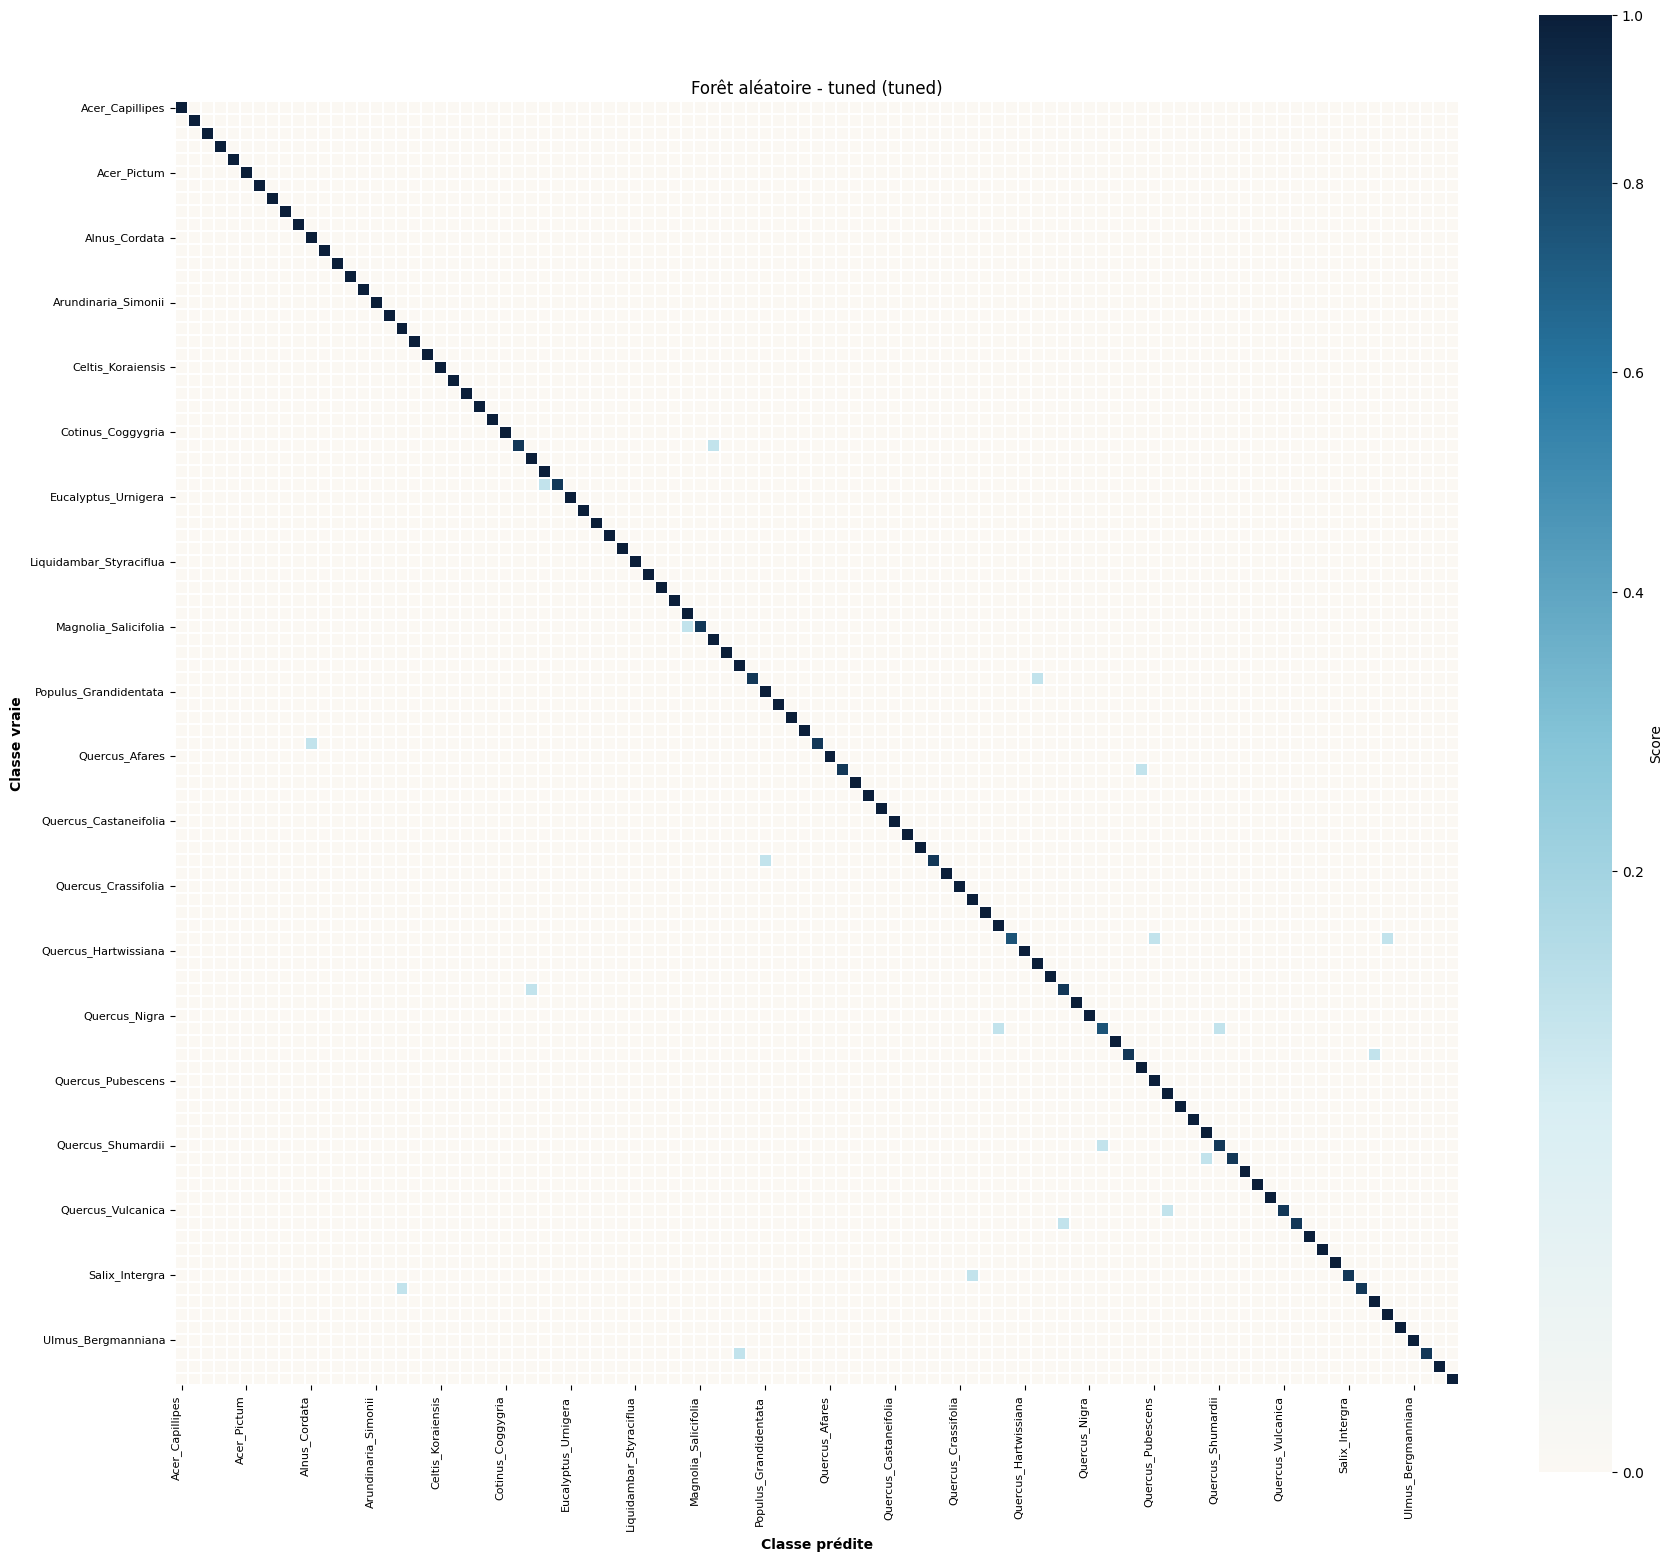

In [8]:
resume_confusions = construire_resume_confusions_variantes(
    MODEL_NAME,
    summary_table,
    X,
    y,
    label_encoder,
)
display(
    resume_confusions[[
        "variante",
        "evaluation_stage",
        "val_f1_macro_mean",
        "val_accuracy_mean",
        "generalization_gap_f1_macro",
        "confusion_dominante",
        "nombre_erreurs_dominantes",
    ]].round(4)
)

ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    resume_confusions
    .assign(
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["_ordre", "variante"])
    .reset_index(drop=True)
)

for ligne in catalogue_variantes.to_dict("records"):
    variante = str(ligne["variante"])
    predictions_variante = charger_ou_generer_predictions_variante(
        MODEL_NAME,
        variante,
        X,
        y,
        label_encoder=label_encoder,
        root=OUTPUT_ROOT,
    )
    matrice = matrice_confusion_normalisee(
        predictions_variante["y_true"].to_numpy(),
        predictions_variante["y_pred"].to_numpy(),
        label_encoder=label_encoder,
    )
    tracer_matrice_confusion(
        matrice,
        titre=f"{definition['nom_affiche']} - {variante} ({ligne['evaluation_stage']})",
        annot=False,
        intervalle_ticks=5,
    )
    plt.show()


_Diagnostic exploratoire specifique._ Les importances ci-dessous proviennent d'une lecture OOB du meilleur estimateur exploratoire. Elles servent a illustrer des tendances descriptives plus proches de la generalisation que le refit in-sample, sans devenir pour autant un resultat confirmatoire.


In [9]:
importance = calculer_importance_oob_foret_exploratoire(
    tuning["grid"].best_estimator_,
    X,
    y,
    n_repeats=5,
)
display(importance.head(20).round(4))


,feature,importance_mean,importance_std
0,shape48,0.0174,0.0369
1,shape16,0.0171,0.0327
2,shape51,0.0151,0.0400
3,margin31,0.0145,0.0335
4,shape49,0.0144,0.0273
5,shape47,0.0144,0.0332
6,shape15,0.0132,0.0259
7,shape61,0.0128,0.0314
8,shape17,0.0127,0.0243
9,shape19,0.0126,0.0283


### Convergence OOB — diagnostic exploratoire

Score OOB (out-of-bag) en fonction du nombre d'arbres, refitte sur le sous-ensemble de developpement (80 %).
Ce diagnostic illustre la convergence de l'ensemble — il ne remplace pas l'évaluation par validation croisée imbriquée.

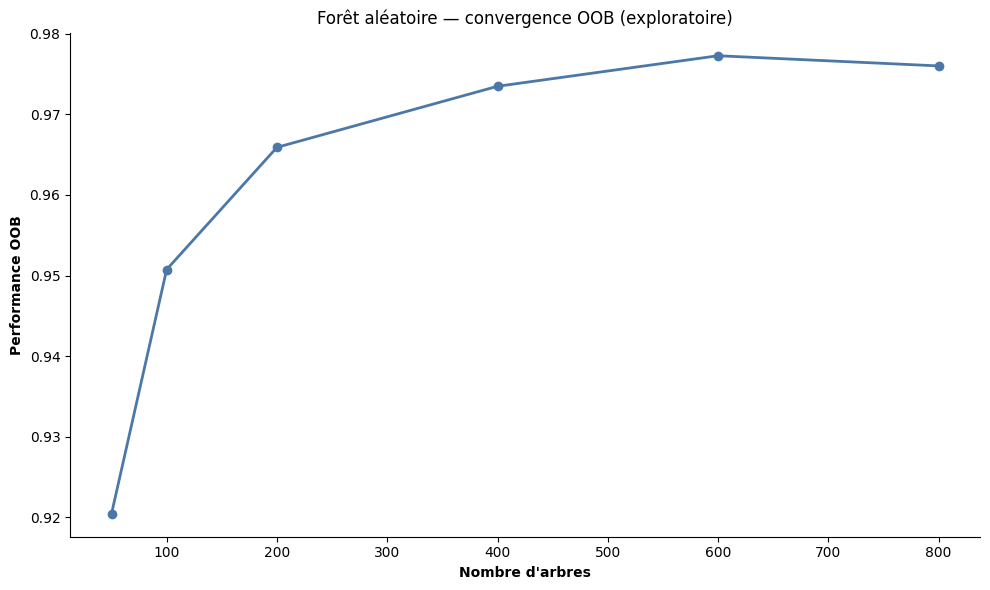

,n_estimators,oob_score
0,50,0.9205
1,100,0.9508
2,200,0.9659
3,400,0.9735
4,600,0.9773
5,800,0.9760


In [10]:
from src.models.pipelines import creer_estimateur

oob_data = oob_vs_n_estimators(creer_estimateur("foret_aleatoire"), X, y)
tracer_oob_vs_n_estimators(
    oob_data,
    titre=f"{definition['nom_affiche']} — convergence OOB (exploratoire)",
)
plt.show()
display(oob_data.round(4))

## 7. Interpretation

Le texte ci-dessous reste automatiquement borne par les chiffres obtenus dans ce notebook.
Il ne doit pas servir a sur-interpreter des signaux purement exploratoires.


In [11]:
best_untuned = untuned_table.sort_values("val_f1_macro_mean", ascending=False).iloc[0]
tuned_row = summary_table.loc[summary_table["variante"] == "tuned"].iloc[0]
lignes = [
    f"- Meilleure variante non tunée : `{best_untuned['variante']}` avec F1-macro = `{best_untuned['val_f1_macro_mean']:.4f}`.",
    f"- Estimation confirmatoire de la variante ajustée en validation croisée imbriquée : F1-macro = `{tuned_row['val_f1_macro_mean']:.4f}` et accuracy = `{tuned_row['val_accuracy_mean']:.4f}`.",
]

delta_tuning = tuned_row["val_f1_macro_mean"] - best_untuned["val_f1_macro_mean"]
if abs(delta_tuning) < 0.005:
    lignes.append(
        "- L'ajustement ne change pas matériellement la lecture scientifique par rapport à la meilleure variante exploratoire."
    )
elif delta_tuning > 0:
    lignes.append(
        f"- L'ajustement confirme un gain de `{delta_tuning:+.4f}` en F1-macro par rapport à la meilleure variante exploratoire."
    )
else:
    lignes.append(
        f"- La validation croisée imbriquée donne une estimation plus prudente que l'exploration en validation croisée simple (delta F1-macro = `{delta_tuning:+.4f}`)."
    )

display(Markdown("\n".join(lignes)))


- Meilleure variante non tunée : `default` avec F1-macro = `0.9764`.
- Estimation confirmatoire de la variante ajustée en validation croisée imbriquée : F1-macro = `0.9702` et accuracy = `0.9747`.
- La validation croisée imbriquée donne une estimation plus prudente que l'exploration en validation croisée simple (delta F1-macro = `-0.0062`).

### Figure finale des variantes pour le rapport

Cette cellule lit les metriques canoniques dans `results/<modele>/metrics/`, reconstruit le tableau final des variantes et regenere la figure de synthese du rapport, en incluant explicitement la variante `tuned`.

,variante,f1_macro,accuracy,evaluation_stage,statut
0,default,0.9764,0.9785,baseline,exploratoire
1,restricted_depth,0.9345,0.9445,improved_untuned,exploratoire
2,tuned,0.9702,0.9747,tuned,confirmatoire


WindowsPath('results/foret_aleatoire/figures/core/fig_rf_comparaison_variantes.png')

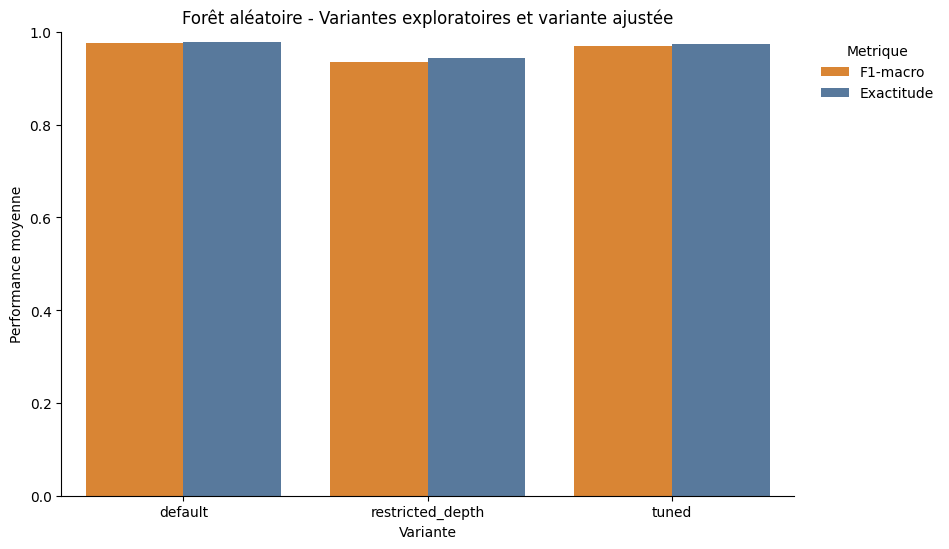

In [12]:
from pathlib import Path

from src.notebook_support import (
    charger_tableau_variantes_modele,
    construire_tableau_variantes_rapport,
)
from src.plots import tracer_comparaison_variantes_rapport

summary_table_report = charger_tableau_variantes_modele("foret_aleatoire")
display(construire_tableau_variantes_rapport(summary_table_report).round(4))

ax = tracer_comparaison_variantes_rapport(
    summary_table_report,
    titre="Forêt aléatoire - Variantes exploratoires et variante ajustée",
)
output_path = OUTPUT_ROOT / "foret_aleatoire" / "figures" / "core" / "fig_rf_comparaison_variantes.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(output_path, dpi=170, bbox_inches="tight")
output_path


## 8. Vérification secondaire sur le jeu de corroboration

Cette section reste strictement additive. Le jeu de corroboration gelé de `20 %` n'intervient ni dans le choix des variantes, ni dans le tuning, ni dans le classement principal.
Il sert uniquement à corroborer, sur un sous-ensemble jamais vu pendant la modélisation, l'écart entre la variante `tuned` et la meilleure variante non tunée retenue sur le jeu de développement.


,variante,f1_macro_holdout,accuracy_holdout,role,corroboration_scope,ranking_eligible,origin,delta_f1_vs_reference
0,default,0.9842,0.9848,reference,corroboration_only,False,exploratory_refit,0.0
1,tuned,0.9842,0.9848,tuned,corroboration_only,False,exploratory_refit,0.0


- Référence de corroboration : `default` avec F1-macro = `0.9842`.
- Variante ajustée sur le jeu de corroboration: F1-macro = `0.9842` et accuracy = `0.9848`.
- Écart de corroboration `ajustée - référence` : `+0.0000` en F1-macro.
- Cette lecture reste secondaire : le classement principal du rapport repose toujours sur la validation croisée imbriquée du jeu de développement.

### Lecture descriptive de toutes les variantes sur le jeu de corroboration

,variante,f1_macro_holdout,accuracy_holdout,role,delta_f1_vs_reference
0,default,0.9842,0.9848,reference,0.0000
1,restricted_depth,0.9468,0.9545,untuned,-0.0374
2,tuned,0.9842,0.9848,tuned,0.0000


_Ce graphique est purement descriptif. Il n'est pas utilisé pour choisir la variante de référence ni pour redéfinir le classement. La référence de corroboration reste déterminée à partir des résultats exploratoires sur le jeu de développement._

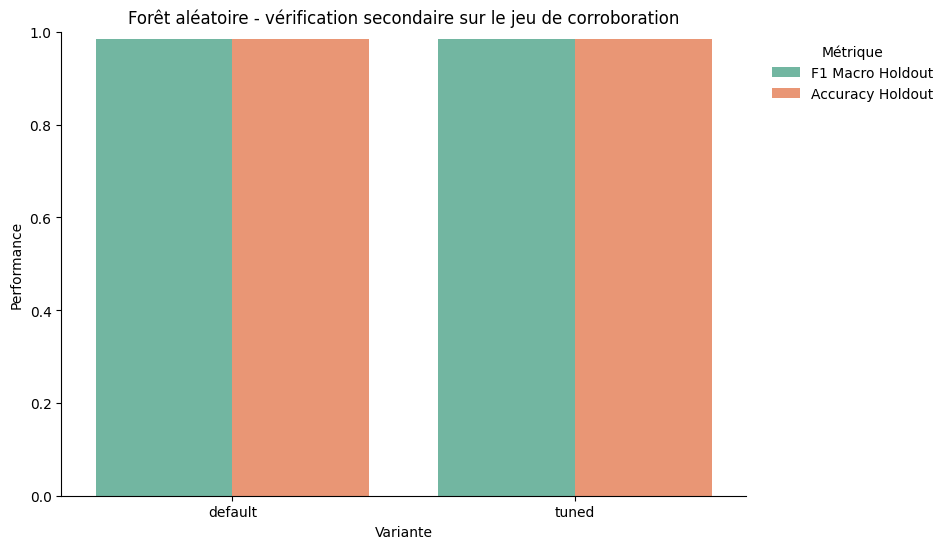

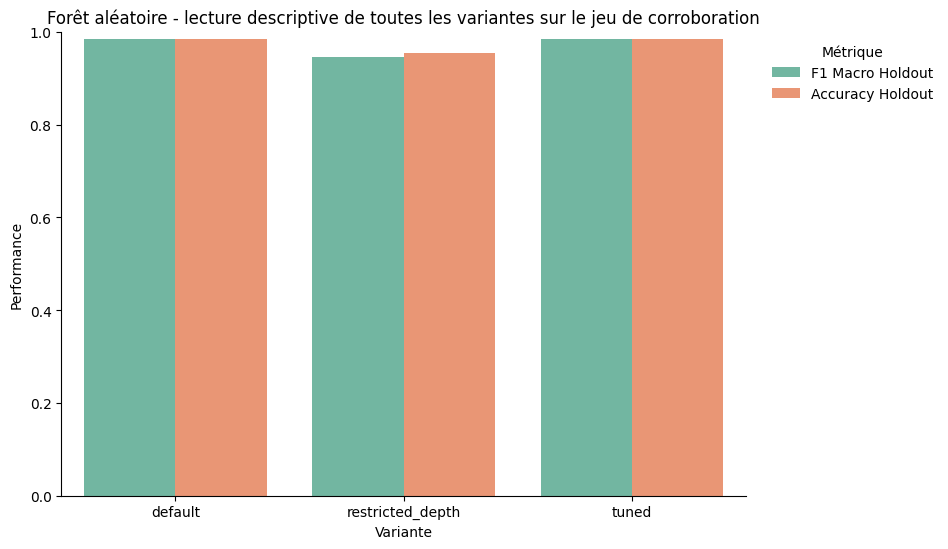

In [13]:
tableau_corroboration = construire_tableau_corroboration_secondaire(tuning["metrics"])
if tableau_corroboration.empty:
    display(Markdown("_Aucune corroboration sur le jeu de corroboration publiée pour ce modèle._"))
else:
    display(tableau_corroboration.round(4))

    axe_corroboration = tracer_comparaison_variantes(
        tableau_corroboration,
        ["f1_macro_holdout", "accuracy_holdout"],
        titre=f"{definition['nom_affiche']} - vérification secondaire sur le jeu de corroboration",
    )
    axe_corroboration.set_ylim(0.0, 1.0)


    reference_row = tableau_corroboration.loc[tableau_corroboration["role"] == "reference"].iloc[0]
    ligne_ajustee_corroboration = tableau_corroboration.loc[tableau_corroboration["role"] == "tuned"].iloc[0]
    ecart_corroboration = ligne_ajustee_corroboration["f1_macro_holdout"] - reference_row["f1_macro_holdout"]
    lignes_corroboration = [
        f"- Référence de corroboration : `{reference_row['variante']}` avec F1-macro = `{reference_row['f1_macro_holdout']:.4f}`.",
        f"- Variante ajustée sur le jeu de corroboration: F1-macro = `{ligne_ajustee_corroboration['f1_macro_holdout']:.4f}` et accuracy = `{ligne_ajustee_corroboration['accuracy_holdout']:.4f}`.",
        f"- Écart de corroboration `ajustée - référence` : `{ecart_corroboration:+.4f}` en F1-macro.",
        "- Cette lecture reste secondaire : le classement principal du rapport repose toujours sur la validation croisée imbriquée du jeu de développement.",
    ]
    display(Markdown("\n".join(lignes_corroboration)))

    display(Markdown("### Lecture descriptive de toutes les variantes sur le jeu de corroboration"))
    tableau_corroboration_descriptif = construire_tableau_corroboration_descriptive_variantes(tuning["metrics"])
    if tableau_corroboration_descriptif.empty:
        display(Markdown("_Aucune vue descriptive toutes variantes n'est disponible pour ce mod?le._"))
    else:
        display(tableau_corroboration_descriptif.round(4))
        axe_corroboration_descriptif = tracer_comparaison_variantes(
            tableau_corroboration_descriptif,
            ["f1_macro_holdout", "accuracy_holdout"],
            titre=f"{definition['nom_affiche']} - lecture descriptive de toutes les variantes sur le jeu de corroboration",
        )
        axe_corroboration_descriptif.set_ylim(0.0, 1.0)
        display(Markdown(
            "_Ce graphique est purement descriptif. Il n'est pas utilisé pour choisir la variante de référence ni pour redéfinir le classement. La référence de corroboration reste déterminée à partir des résultats exploratoires sur le jeu de développement._"
        ))
